# Cargar y preparar los datos

In [1]:
#@title Importar librerías
# Trabajar con data frames
import pandas as pd
#Operaciones
import numpy as np
#División en muestras para validación cruzada
from sklearn.model_selection import train_test_split
# Obtener el modelo de regresion y predicciones
import statsmodels.api as sm
#Evaluación precisión y discriminación
from sklearn.metrics import accuracy_score,roc_auc_score
from scipy.stats.distributions import chi2
#Graficar
import matplotlib.pyplot as plt

In [2]:
#@title Leer datos y explorar
df = pd.read_csv('dataset_CHD.csv')
print(df.describe().round(3))
print('')
print('Sujetos con enfermedad cardiaca')
print(df['CHD'].value_counts())

            ID      AGE  AGEGRP      CHD
count  100.000  100.000  100.00  100.000
mean    50.500   44.380    4.48    0.430
std     29.011   11.721    2.24    0.498
min      1.000   20.000    1.00    0.000
25%     25.750   34.750    2.75    0.000
50%     50.500   44.000    4.00    0.000
75%     75.250   55.000    7.00    1.000
max    100.000   69.000    8.00    1.000

Sujetos con enfermedad cardiaca
CHD
0    57
1    43
Name: count, dtype: int64


In [3]:
#@title División de grupos con una semilla
X1_train, X1_test, y1_train, y1_test,train_idx, test_idx  = train_test_split(
  df['AGE'].values,
  df['CHD'].values, range(len(df)),
  train_size   = 0.9,
  random_state = 131,
  shuffle      = True)

# Para variables con k categprías se usan k-1 variables
dummies=pd.get_dummies(df['AGEGRP'].drop(columns='CHD'), prefix='Age', drop_first=True, dtype=int)
# Se asignan las variables independientes a los subconjuntos
X2_train=dummies.iloc[train_idx]
X2_test=dummies.iloc[test_idx]

# Regresión con una variable discreta (Edad)

In [4]:
#@title Obtención del modelo
# Adición de constante para la interseccion
X1_train = sm.add_constant(X1_train, prepend=True)
# Definicion del modelo
modelo1 = sm.Logit(endog=y1_train, exog=X1_train)
# Estimacion de parámetros con MLE
modelo1 = modelo1.fit()

Optimization terminated successfully.
         Current function value: 0.546374
         Iterations 6


In [5]:
#@title Valores, predicciones y precisión del modelo

#Se añade la constante de isntersección al subconjunto de prueba
X1_test = sm.add_constant(X1_test, prepend=True)
#Predicciones con los valores del subconjunto de prueba
predicciones1 = modelo1.predict(exog = X1_test)
#Binarización de la probabilidad
clasificacion1 = np.where(predicciones1<0.5, 0, 1)
# Cálculo de precisión y discriminación
precision = accuracy_score(y1_test, clasificacion1)
roc = roc_auc_score(y1_test, predicciones1)

#Imprimir resultados del modelo
print(modelo1.summary())
print('')
print(f"Precisión: {precision:.3f}")
print(f"Discriminación con curvas ROC: {roc:.3f}")

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                   90
Model:                          Logit   Df Residuals:                       88
Method:                           MLE   Df Model:                            1
Date:                Fri, 12 Jun 2026   Pseudo R-squ.:                  0.2015
Time:                        02:14:27   Log-Likelihood:                -49.174
converged:                       True   LL-Null:                       -61.581
Covariance Type:            nonrobust   LLR p-value:                 6.313e-07
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.1099      1.176     -4.344      0.000      -7.416      -2.804
x1             0.1061      0.025      4.281      0.000       0.058       0.155

Precisión: 0.800
Discriminación con curvas ROC: 0.8

# Regresión con variable categórica (Grupos de edad)

In [6]:
#@title Definicion modelo 2
#Se añade la intersección
X2_train = sm.add_constant(X2_train, prepend=True)
modelo2 = sm.Logit(endog=y1_train, exog=X2_train,)
#Estimacion de variables con MLE
modelo2 = modelo2.fit()

Optimization terminated successfully.
         Current function value: 0.551043
         Iterations 6


In [7]:
# Adicion de la cosntante al grupo de prueba del M2
X2_test = sm.add_constant(X2_test, prepend=True)
#Predicciones con los valores del subconjunto de prueba
predicciones2 = modelo2.predict(exog = X2_test)
#Binarización de la probabilidad
clasificacion2 = np.where(predicciones2<0.5, 0, 1)
# Cálculo de precisión y discriminación
precision2 = accuracy_score(y1_test, clasificacion2)
roc2 = roc_auc_score(y1_test, predicciones2)
#Imprimir resultados del modelo
print(modelo2.summary())
print('')
print(f"Precisión: {precision2:.3f}")
print(f"Discriminación con curvas ROC: {roc2:.3f}")

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                   90
Model:                          Logit   Df Residuals:                       82
Method:                           MLE   Df Model:                            7
Date:                Fri, 12 Jun 2026   Pseudo R-squ.:                  0.1947
Time:                        02:14:44   Log-Likelihood:                -49.594
converged:                       True   LL-Null:                       -61.581
Covariance Type:            nonrobust   LLR p-value:                  0.001151
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.0794      1.061     -1.961      0.050      -4.158      -0.001
Age_2          0.3747      1.310      0.286      0.775      -2.193       2.942
Age_3          0.6931      1.323      0.524      0.6

# Comparación de los dos modelos

In [33]:
#@title Calculo de variables necesarias para la comparacion
#LikelihoodRatio de M1 y M2
LR=(-2)*(modelo1.llf-modelo2.llf)
#Valor Critico X^2
crit=chi2.ppf(1-0.05, modelo2.df_model-modelo1.df_model)
#p-value suponiendo entre M1 y M2
p = chi2.sf(LR, 6)
#Valores de x para extrapolación
grid_X1 = np.linspace(
    start = min(df['AGE']),
    stop  = max(df['AGE']),
    num   = 200)
#Categorización de los valores de edad
grid_X2 = np.digitize(grid_X1, [20, 30, 35, 40, 45, 50, 55, 60])
#Desglose de variables k-1 variables dummy
dummies2 = pd.get_dummies(grid_X2, prefix='Age', drop_first=True, dtype=int)
#Se añaden la columna de interseccion a los 4 arreglos para predicciones
grid_X1 = sm.add_constant(grid_X1, prepend=True) #X para curva logística M1
X1_com=sm.add_constant(df['AGE'], prepend=True) #X para predicciones M1
dummies2 = sm.add_constant(dummies2, prepend=True) #X para la escalera de M2
dummiesCom=sm.add_constant(dummies, prepend=True) #X para predicciones M2
#Probabilidades para el arreglo ficticio M2 y M1
prediccionesCom1 = modelo1.predict(exog = grid_X1)
prediccionesCom2 = modelo2.predict(exog = dummies2)
#Binarización con desplazamiento para su visualización
predicR1=np.where(modelo1.predict(exog=X1_com)<0.5, 0.025, 0.975)
predicR2=np.where(modelo2.predict(exog=dummiesCom)<0.5, 0.055, 0.945)

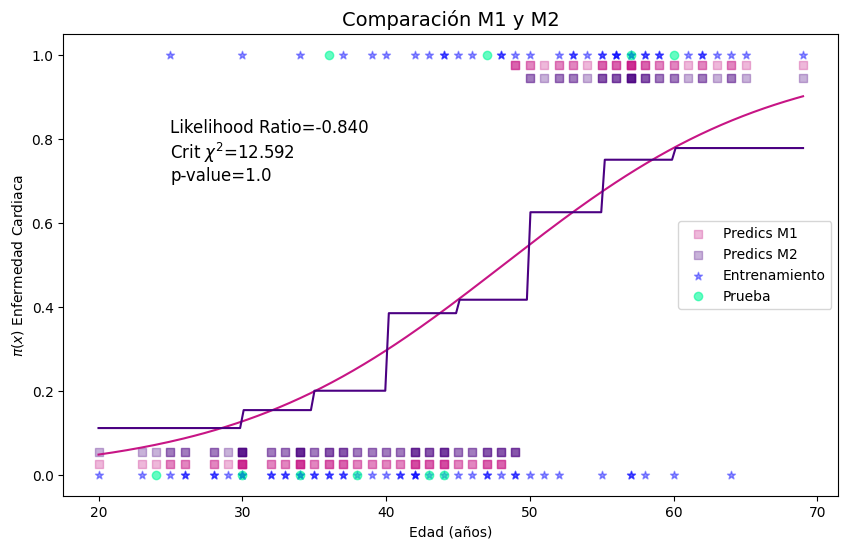

In [52]:
#@title Graficar ambos modelos
fig, ax = plt.subplots(figsize=(10, 6))
#Curva y escalera con arreglo artificial
ax.plot(grid_X1[:, 1], prediccionesCom1, color = "mediumvioletred")
ax.plot(grid_X1[:, 1], prediccionesCom2, color = "indigo")
#Predicciones de cada modelo para los valores de todo el conjunto
ax.scatter(df['AGE'], predicR1, color = "mediumvioletred",marker='s',alpha=0.3, label='Predics M1')
ax.scatter(df['AGE'], predicR2, color = "indigo",marker='s',alpha=0.3,label='Predics M2')
#Datos originales usados como entrenamiento y como prueba
ax.scatter(X1_train[:, 1],y1_train, color = "b",marker='*',alpha=0.4, label='Entrenamiento')
ax.scatter(X1_test[:, 1],y1_test, color = "mediumspringgreen", alpha=0.6, label='Prueba')
#Datos de la gráfica
ax.set_title("Comparación M1 y M2",fontsize=14)
ax.set_ylabel(r"$\pi(x)$ Enfermedad Cardiaca")
ax.set_xlabel("Edad (años)");
plt.legend()
plt.text(25, 0.7, f'Likelihood Ratio={LR:.3f}\nCrit $\\chi^2$={crit:.3f}\np-value={p}', fontsize=12, color='k')
plt.show()